## Plot observed and predicted SFS for any ancestry

In [26]:
# --- make parent folder importable ---
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))  # points to Paper_SFS/

# --- usual imports ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import matplotlib.ticker as ticker
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm, gamma
from scipy.integrate import simpson, trapezoid
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import dask
import dask.dataframe as dd
import re
import dask.bag as db
import csv
from tqdm import tqdm
from dask.diagnostics import ProgressBar
from concurrent.futures import ProcessPoolExecutor
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
import random
import json

# --- import your project modules (files in Paper_SFS/) ---
import Gen_SFS_with_s_demography
import plot_SFS

# (optional) pull specific functions
# from Gen_SFS_with_s import calc_SFS_k
# from plot_SFS import plot_sfs


In [2]:
# ----------------------------------------------------------
# Fixed ancestry colors: consistent across all figures
# ----------------------------------------------------------
ANCESTRY_COLORS = {
    "NFE":     "#1f77b4",   # blue
    "AFR":     "#d62728",   # red
    "SAS":     "#9467bd",   # purple
    "EAS":     "#000000",   # black
    "AMR":     "#8c564b",   # brown-grey
    "FIN":     "#ff7f0e",   # orange
    "all":     "#2ca02c",   # green
    "de novo": "#FFC000"    # gold/yellow
}


def load_mu_params_for_demography(demography="NFE", epoch = 3, single_param = False):

    if single_param == True:
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_NFE.txt', sep = '\t')
    elif demography == "NFE" or demography == "schraiber_et_al":
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt', sep = '\t')
    elif demography == "all":
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_all.txt', sep = '\t')
    else:
        df_mu_var_p = pd.read_csv(f'../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_{demography}_epoch_{epoch}.txt', sep = '\t')
         
    return df_mu_var_p
    

def load_demography_result(json_file, demography, epoch_no):
    with open(json_file, "r") as f:
        records = json.load(f)
    for rec in records:
        if rec["demography"] == demography and rec["epoch_no"] == epoch_no:
            return rec
        else:
            rec = {"params" : []}
    return rec
    

def compute_predicted_SFS_for_MR(row_mu, demography, params_dem, mu_low_mu, AN, kmax=5000):
    mean_mu = row_mu["mean_mu"]
    var_mu  = row_mu["var_mu"]
    p_mu    = row_mu["p_mu"]

    # Build SFS for this mu distribution
    if demography == "NFE" or demography == "schraiber_et_al":

        _, _, _, SFS_gamma = Gen_SFS_with_s_demography.compute_SFS_gamma_mu_var(mu=mean_mu, var=var_mu, s=0, demography="NFE", n=AN, params=params_dem,
                                                                         model="original", kmax=kmax)

        _, _, _, SFS_low_mu = Gen_SFS_with_s_demography.compute_SFS(mu=mu_low_mu, s=0, demography="NFE", n=AN, params=params_dem, model="original",
                                                                kmax=kmax)

    else:

        _, _, _, SFS_gamma = Gen_SFS_with_s_demography.compute_SFS_gamma_mu_var(mu=mean_mu, var=var_mu, s=0, demography=demography, n=AN, params=params_dem,
                                                                         model="original", kmax=kmax)

        _, _, _, SFS_low_mu = Gen_SFS_with_s_demography.compute_SFS(mu=mu_low_mu, s=0, demography=demography, n=AN, params=params_dem, model="original",
                                                                kmax=kmax)

    
    # Mixture of gamma-based SFS and low-mu SFS
    SFS_mix = (1 - p_mu) * SFS_gamma + p_mu * SFS_low_mu

    return SFS_mix


def compute_predicted_SFS_for_MR_1param(row_mu, demography, params_dem, AN, kmax=5000):
    mean_mu = row_mu["mean_mu"]

    # Build SFS for this mu distribution
    if demography == "NFE" or demography == "schraiber_et_al":

        # Compute log(mu_scaled) only once
        _, _, _, SFS_pred = Gen_SFS_with_s_demography.compute_SFS(mu = mean_mu, s = 0, demography="NFE", n=AN, params=params_dem, model="original", kmax=kmax)

    else:

        # Compute log(mu_scaled) only once
        _, _, _, SFS_pred = Gen_SFS_with_s_demography.compute_SFS(mu = mean_mu, s = 0, demography=demography, n=AN, params=params_dem, model="original", kmax=kmax)

    return SFS_pred
    

def plot_SFS_observed_vs_predicted(df_syn, df_mu, demography, params_dem, mu_low_mu, MR_values=None, kmax=5000, fig_save_file = None, single_param = False):

    # If MR_values not provided, use all (limited to max_plots)
    all_MRs = sorted(df_mu["MR"].unique())
    if MR_values is None:
        MR_values = all_MRs

    # Setup grid
    nplots = len(MR_values)
    ncols = 3
    nrows = int(np.ceil(nplots / ncols))

    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
    axes = axes.flatten()

    # Use fixed color
    colors = ANCESTRY_COLORS.get(demography, "#1f77b4")  # fallback: blue

    for idx, MR in enumerate(MR_values):
        ax = axes[idx]

        # Filter syn data for this MR
        df_bin = df_syn[df_syn["MR"] == MR]
        
        if demography == "all":
            ac = df_bin["allele_count"].values
            AN = df_bin["allele_number"].mode().iloc[0]
        elif demography == "schraiber_et_al":
            ac = df_bin["AC_NFE"].values
            AN = df_bin["AN_NFE"].mode().iloc[0]
        else:
            ac = df_bin[f"AC_{demography}"].values
            AN = df_bin[f"AN_{demography}"].mode().iloc[0]

        # Observed SFS (smoothed)
        mean_syn, density_syn = plot_SFS.plot_xy(ac, AN, 30, 2)  # your smoothing function

        # keep only k > 0
        mask_obs = (mean_syn > 0) & (mean_syn<=1000)
        mean_syn = mean_syn[mask_obs]
        density_syn = density_syn[mask_obs]

        # Model SFS
        row_mu = df_mu[df_mu["MR"] == MR].iloc[0]
        if single_param == True:
            SFS_pred = compute_predicted_SFS_for_MR_1param(row_mu, demography, params_dem, AN, kmax)
        else:
            SFS_pred = compute_predicted_SFS_for_MR(row_mu, demography, params_dem, mu_low_mu, AN, kmax)

        k = np.arange(len(SFS_pred))
        mask_pred = (k > 0) & (k<=1000)
        k = k[mask_pred]
        SFS_pred = SFS_pred[mask_pred]

        # Plot observed
        ax.scatter(mean_syn, density_syn, color=colors, s=18, alpha=0.8, label="Observed")

        # Plot predicted
        ax.plot(k, SFS_pred, color=colors, lw=2, linestyle="--", label="Predicted")

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(0.9, 1000+0.1)
        # ax.set_title(f"{demography} — MR={MR:.3g}")
        ax.set_xlabel("Allele count")
        ax.set_ylabel("Density")
        # ax.grid(alpha=0.3)
        ax.legend()

    # Remove empty subplots
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    if fig_save_file is not None:
        plt.savefig(fig_save_file, dpi=300, format = "svg")
        
    plt.tight_layout()
    plt.show()


def run_SFS_validation(demography, epoch_no, json_file="../Demography_estimation/demography_results.json", mu_low_mu = 2e-10, MR_values=None, fig_save_file = None, single_param = False):

    # Load syn data
    df_syn = pd.read_csv("../Data/synonymous_data.txt.gz", sep="\t", compression = "gzip")

    # Load mu parameters
    df_mu = load_mu_params_for_demography(demography = demography, epoch = epoch_no, single_param = single_param)

    # Load demography parameters
    params_rec = load_demography_result(json_file, demography, epoch_no)

    # Run plotting
    plot_SFS_observed_vs_predicted(df_syn=df_syn, df_mu=df_mu, demography=demography, params_dem=params_rec["params"], mu_low_mu=mu_low_mu,
                                   MR_values=MR_values, fig_save_file = fig_save_file, single_param = single_param)


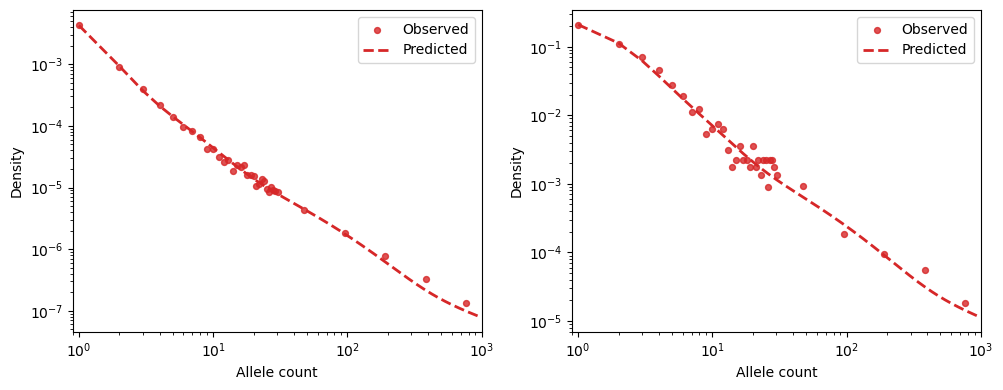

In [4]:
demography = "AFR"
run_SFS_validation(demography, epoch_no=3, MR_values= [0.020, 3.219], mu_low_mu = 2e-10, single_param = False, fig_save_file=f"../Figures/SFS_{demography}.svg")

In [2]:
df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt', sep = '\t') # /home/prk534/Pop_gen_simulator/demograph_Roulette_scaling/results_mu_var_p_all_anc_together.txt
df_mu_var_p["mean"] = df_mu_var_p["mean_mu"]/(4*14448)
df_mu_var_p["var"] = df_mu_var_p["var_mu"]/((4*14448)**2)
df_mu_var_p[80:90]

,MR,p_mu,mean_mu,var_mu,max_loglikelihood,mean,var
80,1.661,0.027351,0.005435,0.000003,-59530.971565,9.404406e-08,9.219473e-16
81,1.715,0.018021,0.005643,0.000003,-77187.170665,9.764413e-08,7.623282e-16
82,1.772,0.026311,0.005868,0.000003,-79839.479335,1.015307e-07,9.752677e-16
83,1.833,0.018315,0.005923,0.000003,-90012.668560,1.024800e-07,8.254316e-16
84,1.897,0.019196,0.006109,0.000003,-99388.838059,1.057027e-07,9.375248e-16
85,1.966,0.014163,0.006364,0.000003,-113514.372875,1.101138e-07,9.075117e-16
86,2.040,0.015136,0.006547,0.000003,-127106.225968,1.132904e-07,9.101696e-16
87,2.120,0.012338,0.006623,0.000003,-146436.022187,1.145949e-07,8.304832e-16
88,2.207,0.012465,0.006951,0.000004,-125544.540145,1.202782e-07,1.094130e-15
89,2.303,0.011660,0.007067,0.000003,-131017.469085,1.222809e-07,9.772862e-16


In [4]:
print(df_mu_var_p[df_mu_var_p["MR"]==0.020])
print(df_mu_var_p[df_mu_var_p["MR"]==3.219])

     MR      p_mu   mean_mu        var_mu  max_loglikelihood          mean  \
1  0.02  0.000078  0.000071  3.339915e-14     -842807.318386  1.231779e-09   

            var  
1  1.000000e-23  
       MR      p_mu   mean_mu   var_mu  max_loglikelihood          mean  \
95  3.219  0.004311  0.009499  0.00001      -10710.353121  1.643695e-07   

             var  
95  2.869028e-15  


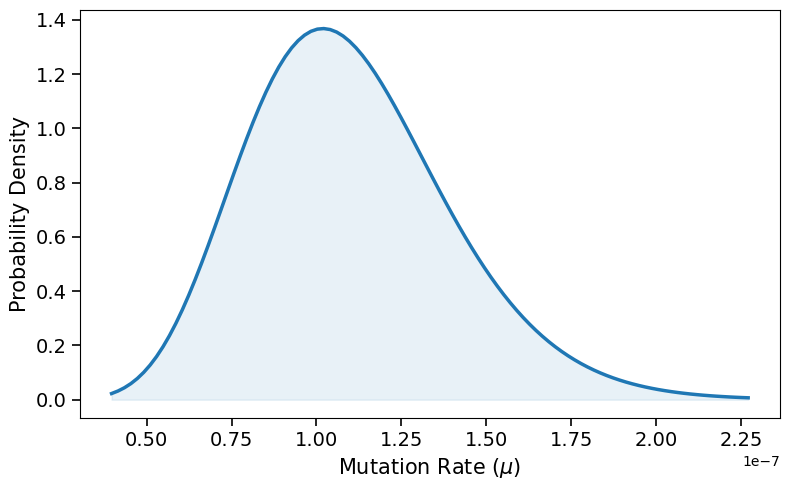

In [ ]:
# Create gamma distribution for any MR

# 1. Specified Mean and Variance
mean = df_mu_var_p["mean"].values[85]
variance = df_mu_var_p["var"].values[85]

# 2. Calculate Shape (a) and Scale (theta)
# SciPy uses shape (a) and scale (theta)
shape = mean**2 / variance
scale = variance / mean

# 3. Scientific Notation Formatter (3.0 x 10^-7 style)
def format_sci_latex(v):
    s = f"{v:.1e}"
    base, exp = s.split('e')
    return f"${float(base):.1f} \\times 10^{{{int(exp)}}}$"

# 4. Generate Data
# Use ppf (Percent Point Function) to find the range covering 99.8% of the distribution
x = np.linspace(gamma.ppf(0.001, shape, scale=scale), 
                gamma.ppf(0.999, shape, scale=scale), 100)
pdf = gamma.pdf(x, shape, scale=scale)

# 5. Plotting
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(x, pdf, color='#1f77b4', lw=2.5)
ax.fill_between(x, pdf, color='#1f77b4', alpha=0.1)

# Bold labels and clean ticks
@ticker.FuncFormatter
def major_formatter(x, pos):
    return f"{x*1e-7:.1f}" # Show the significant digits

ax.set_xlabel(r"Mutation Rate ($\mu$)", fontsize=15)
ax.yaxis.set_major_formatter(major_formatter)
ax.set_ylabel("Probability Density", fontsize=15)
ax.tick_params(axis="both", which="major", labelsize=11, width=1.2, length=6)

plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

plt.tight_layout()
plt.savefig("../Figures/gamma_dist_MR.svg", dpi=300, format = "svg")
plt.show()


# Scratch Work

In [ ]:
# Faster way to check and above is the more cleaner way

In [10]:
df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt', sep = '\t') # /home/prk534/Pop_gen_simulator/demograph_Roulette_scaling/results_mu_var_p_all_anc_together.txt
df_mu_var_p["mean"] = df_mu_var_p["mean_mu"]/(4*14448)
df_mu_var_p.iloc[84:98]

,MR,p_mu,mean_mu,var_mu,max_loglikelihood,mean
84,1.897,0.019196,0.006109,0.000003,-99388.838059,1.057027e-07
85,1.966,0.014163,0.006364,0.000003,-113514.372875,1.101138e-07
86,2.040,0.015136,0.006547,0.000003,-127106.225968,1.132904e-07
87,2.120,0.012338,0.006623,0.000003,-146436.022187,1.145949e-07
88,2.207,0.012465,0.006951,0.000004,-125544.540145,1.202782e-07
89,2.303,0.011660,0.007067,0.000003,-131017.469085,1.222809e-07
90,2.408,0.011500,0.007507,0.000005,-124272.650514,1.298911e-07
91,2.526,0.009894,0.007823,0.000004,-95787.421050,1.353656e-07
92,2.659,0.007227,0.008182,0.000004,-91698.759182,1.415816e-07
93,2.813,0.010184,0.008505,0.000005,-68233.165295,1.471712e-07


In [6]:
df = pd.read_csv("../Data/syn_anc/all_1461892.txt.gz", sep="\t", compression = "gzip")
demography = "all"
epoch = 3
AN = 1461892

df_syn_filtered = df[df['allele_count']<=5000]

# df_mu_var_p = pd.read_csv(f'../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_{demography}_epoch_{epoch}.txt', sep = '\t')
df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_all.txt', sep = '\t') # /home/prk534/Pop_gen_simulator/demograph_Roulette_scaling/results_mu_var_p_all_anc_together.txt
mean_mu_values = df_mu_var_p['mean_mu'].values
var_mu_values = df_mu_var_p['var_mu'].values
p_mu_values = df_mu_var_p['p_mu'].values

mu_var_pairs = np.column_stack((mean_mu_values, var_mu_values))

with open("../Demography_estimation/demography_results.json", "r") as f:
    records = json.load(f)
    for rec in records:
        if rec["demography"] == demography and rec["epoch_no"] == epoch:
            params = rec["params"]
            break
        else:
            params = []
print(params)
SFS_eachp_s  = Gen_SFS_with_s_demography.compute_SFS_gamma_mu_var_pairs(mu_var_pairs, [0], demography, AN, params = params, model = "original")#, 1112012)
SFS_eachp = SFS_eachp_s[:, 0, :]

p_mu_values = p_mu_values.reshape(-1, 1)

_, _, _, SFS_low_mu = Gen_SFS_with_s_demography.compute_SFS(mu=2e-10, s=0, demography=demography, n=AN, params=params, model="original",
                                                                kmax=5000)

# Ensure SFS_low_mu is shape (1, 5001)
SFS_low_mu = SFS_low_mu.reshape(1, -1)
SFS_each = (1-p_mu_values)*SFS_eachp + p_mu_values*SFS_low_mu

[]


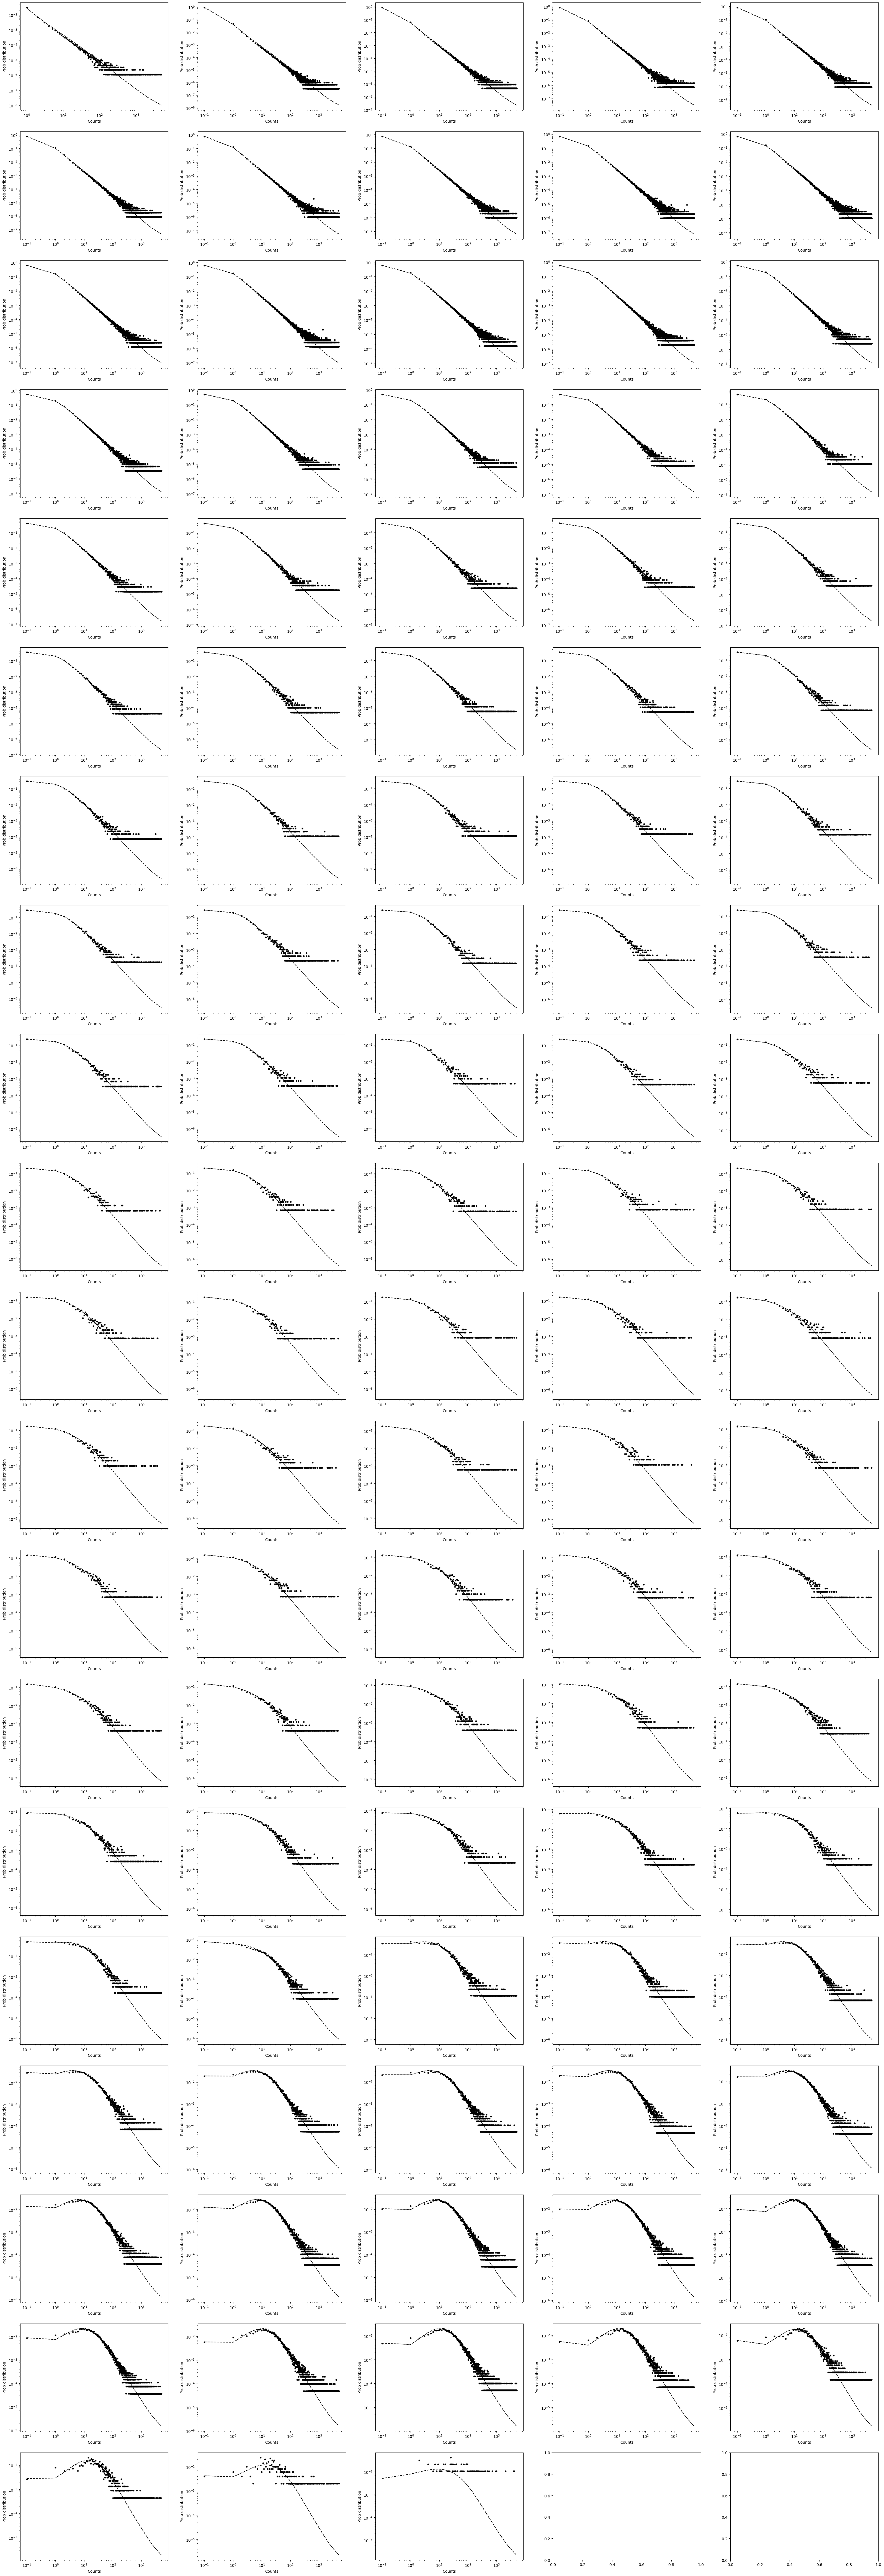

In [7]:
MR_counts = df_syn_filtered['MR'].value_counts().sort_index()
MR_filtered = MR_counts[MR_counts>0].index

fig, axes = plt.subplots(math.ceil(len(mean_mu_values)/5), 5, figsize=(40, math.ceil(len(mean_mu_values)/5)*6))
axes = axes.flatten()
eps = 1e-1

for bin_no in range(len(mean_mu_values)):
    MR_curr = MR_filtered[bin_no+1]
    tot = df[df['MR'] == MR_curr][['count']].sum()
    # Modify x-values before plotting
    x_values = df_syn_filtered[df_syn_filtered["MR"] == MR_curr]["allele_count"].replace(0, eps)
    x_values_an = np.insert(np.arange(1,5001,dtype = float), 0, eps)
    y_values = df_syn_filtered[df_syn_filtered["MR"]==MR_curr][["count"]]/tot
    if bin_no>0:
        axes[bin_no].scatter(x_values, y_values, s= 10, c = 'black')
        axes[bin_no].plot(x_values_an, SFS_each[bin_no], '--', c = 'black')
    else:
        axes[bin_no].scatter(x_values[1:], y_values[1:], s= 10, c = 'black')
        axes[bin_no].plot(x_values_an[1:], SFS_each[bin_no, 1:], '--', c = 'black')
    #print([y_values[0:3], SFS_each[bin_no, 0:3]])
    axes[bin_no].set_yscale('log')
    axes[bin_no].set_xscale('log')
    axes[bin_no].set_ylabel("Prob distribution")
    axes[bin_no].set_xlabel("Counts")
    #axes[bin_no].set_xlim(0.009, 2.5)
    #axes[bin_no].set_ylim(0.001, 1)

In [2]:
df1 = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt', sep = '\t') # 
df2 = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE_1.txt', sep = '\t') # /home/prk534/Pop_gen_simulator/demograph_Roulette_scaling/results_mu_var_p_all_anc_together.txt
np.allclose(
    df1.to_numpy(),
    df2.to_numpy(),
    rtol=1e-9,
    atol=1e-7,
    equal_nan=True
)


True

In [3]:
diff = df1.compare(df2)
diff_rows = diff.index.unique()
rows_that_differ = diff.index.unique()

print(df1.loc[rows_that_differ])
print(df2.loc[rows_that_differ])


       MR      p_mu   mean_mu        var_mu  max_loglikelihood
3   0.041  0.000026  0.000139  3.339915e-14     -671669.636024
33  0.416  0.000084  0.001315  3.505832e-07      -14651.821874
93  2.813  0.010184  0.008505  4.983876e-06      -68233.165295
       MR      p_mu   mean_mu        var_mu  max_loglikelihood
3   0.041  0.000026  0.000139  3.339915e-14     -671669.635720
33  0.416  0.000084  0.001315  3.505832e-07      -14651.821874
93  2.813  0.010184  0.008505  4.983876e-06      -68233.165295


In [4]:
for col in df1.columns:
    mask = ~(df1[col].eq(df2[col]) | (df1[col].isna() & df2[col].isna()))
    if mask.any():
        print(f"\nColumn {col}:")
        print(df1.loc[mask, col], df2.loc[mask, col])



Column p_mu:
0     0.000119
1     0.000049
2     0.000032
3     0.000084
4     0.000027
        ...   
90    0.004151
91    0.002315
92    0.002290
93    0.003148
95    0.000848
Name: p_mu, Length: 69, dtype: float64 0     0.0
1     0.0
2     0.0
3     0.0
4     0.0
     ... 
90    0.0
91    0.0
92    0.0
93    0.0
95    0.0
Name: p_mu, Length: 69, dtype: float64

Column mean_mu:
0     0.000065
1     0.000100
2     0.000145
3     0.000192
4     0.000241
        ...   
93    0.011770
94    0.012517
95    0.013375
96    0.016674
97    0.016439
Name: mean_mu, Length: 98, dtype: float64 0     0.000406
1     0.000617
2     0.000922
3     0.001250
4     0.001584
        ...   
93    0.059984
94    0.061148
95    0.066326
96    0.068149
97    0.061398
Name: mean_mu, Length: 98, dtype: float64

Column var_mu:
0     3.339915e-14
1     3.339915e-14
2     3.339915e-14
3     3.339915e-14
4     3.339915e-14
          ...     
93    1.971866e-05
94    2.958191e-05
95    2.899086e-05
96    7.878911e

In [8]:
df_merge = df1.merge(df2, on = "MR", how = "left")
df_merge

,MR,p_mu_x,mean_mu_x,var_mu_x,max_loglikelihood_x,p_mu_y,mean_mu_y,var_mu_y,max_loglikelihood_y
0,0.013,0.000051,0.000067,3.339915e-14,-2.644668e+05,0.000119,0.000065,3.339915e-14,-2.646525e+05
1,0.020,0.000121,0.000103,4.003505e-14,-1.255237e+06,0.000049,0.000100,3.339915e-14,-1.256126e+06
2,0.030,0.000070,0.000149,3.339915e-14,-1.214676e+06,0.000032,0.000145,3.339915e-14,-1.215404e+06
3,0.041,0.000023,0.000198,3.339915e-14,-9.754030e+05,0.000084,0.000192,3.339915e-14,-9.758561e+05
4,0.051,0.000060,0.000249,3.403445e-14,-9.482389e+05,0.000027,0.000241,3.339915e-14,-9.486756e+05
...,...,...,...,...,...,...,...,...,...
93,2.813,0.003516,0.012154,1.964580e-05,-7.792014e+04,0.003148,0.011770,1.971866e-05,-7.770019e+04
94,2.996,0.003609,0.012860,2.635501e-05,-3.792076e+04,0.000000,0.012517,2.958191e-05,-3.781774e+04
95,3.219,0.001035,0.013874,3.044554e-05,-1.229558e+04,0.000848,0.013375,2.899086e-05,-1.225868e+04
96,3.507,0.000000,0.017487,8.896779e-05,-2.965926e+03,0.000000,0.016674,7.878911e-05,-2.950600e+03


In [10]:
df_merge["diff_LL"] = df_merge["max_loglikelihood_x"] - df_merge["max_loglikelihood_y"]
df_merge[df_merge["diff_LL"]<-1]

,MR,p_mu_x,mean_mu_x,var_mu_x,max_loglikelihood_x,p_mu_y,mean_mu_y,var_mu_y,max_loglikelihood_y,diff_LL
13,0.151,0.000127,0.000707,3.339915e-14,-889535.169985,0.000085,0.000682,5.390598e-14,-889505.536197,-29.633788
14,0.163,0.000131,0.000756,3.339915e-14,-713629.022564,0.000131,0.000730,3.339915e-14,-713539.623695,-89.398869
15,0.174,0.000116,0.000801,3.339915e-14,-558365.127306,0.000081,0.000772,3.339915e-14,-558249.849592,-115.277714
16,0.186,0.000116,0.000855,3.339915e-14,-428657.940253,0.000105,0.000825,3.339915e-14,-428537.113231,-120.827022
17,0.198,0.000006,0.000906,3.590054e-14,-319688.660558,0.000000,0.000873,3.339915e-14,-319600.726085,-87.934473
...,...,...,...,...,...,...,...,...,...,...
93,2.813,0.003516,0.012154,1.964580e-05,-77920.138937,0.003148,0.011770,1.971866e-05,-77700.186444,-219.952493
94,2.996,0.003609,0.012860,2.635501e-05,-37920.757471,0.000000,0.012517,2.958191e-05,-37817.740054,-103.017417
95,3.219,0.001035,0.013874,3.044554e-05,-12295.580570,0.000848,0.013375,2.899086e-05,-12258.677942,-36.902629
96,3.507,0.000000,0.017487,8.896779e-05,-2965.926210,0.000000,0.016674,7.878911e-05,-2950.600219,-15.325991


In [24]:
# ----------------------------------------------------------
# Fixed ancestry colors: consistent across all figures
# ----------------------------------------------------------
ANCESTRY_COLORS = {
    "NFE":     "#1f77b4",   # blue
    "AFR":     "#d62728",   # red
    "SAS":     "#9467bd",   # purple
    "EAS":     "#000000",   # black
    "AMR":     "#8c564b",   # brown-grey
    "FIN":     "#ff7f0e",   # orange
    "all":     "#2ca02c",   # green
    "de novo": "#FFC000"    # gold/yellow
}


def load_mu_params_for_demography(demography="NFE", epoch = 3, single_param = False):

    if single_param == True:
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_NFE.txt', sep = '\t')
    elif demography == "NFE" or demography == "schraiber_et_al":
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_NFE.txt', sep = '\t')
    elif demography == "all":
        df_mu_var_p = pd.read_csv('../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_all.txt', sep = '\t')
    else:
        df_mu_var_p = pd.read_csv(f'../Mutation_rate_estimation/param_mut_rate/results_mu_var_p_{demography}_epoch_{epoch}.txt', sep = '\t')
         
    return df_mu_var_p
    

def load_demography_result(json_file, demography, epoch_no):
    with open(json_file, "r") as f:
        records = json.load(f)
    for rec in records:
        if rec["demography"] == demography and rec["epoch_no"] == epoch_no:
            return rec
        else:
            rec = {"params" : []}
    return rec
    

def compute_predicted_SFS_for_MR(row_mu, demography, params_dem, mu_low_mu, AN, kmax=5000):
    mean_mu = row_mu["mean_mu"]
    var_mu  = row_mu["var_mu"]
    p_mu    = row_mu["p_mu"]

    # Build SFS for this mu distribution
    if demography == "NFE" or demography == "schraiber_et_al":

        _, _, _, SFS_gamma = Gen_SFS_with_s_demography.compute_SFS_gamma_mu_var(mu=mean_mu, var=var_mu, s=0, demography="NFE", n=AN, params=params_dem,
                                                                         model="original", kmax=kmax)

        _, _, _, SFS_low_mu = Gen_SFS_with_s_demography.compute_SFS(mu=mu_low_mu, s=0, demography="NFE", n=AN, params=params_dem, model="original",
                                                                kmax=kmax)

    else:

        _, _, _, SFS_gamma = Gen_SFS_with_s_demography.compute_SFS_gamma_mu_var(mu=mean_mu, var=var_mu, s=0, demography=demography, n=AN, params=params_dem,
                                                                         model="original", kmax=kmax)

        _, _, _, SFS_low_mu = Gen_SFS_with_s_demography.compute_SFS(mu=mu_low_mu, s=0, demography=demography, n=AN, params=params_dem, model="original",
                                                                kmax=kmax)

    
    # Mixture of gamma-based SFS and low-mu SFS
    SFS_mix = (1 - p_mu) * SFS_gamma + p_mu * SFS_low_mu

    return SFS_mix


def compute_predicted_SFS_for_MR_1param(row_mu, demography, params_dem, AN, kmax=5000):
    mean_mu = row_mu["mean_mu"]

    # Build SFS for this mu distribution
    if demography == "NFE" or demography == "schraiber_et_al":

        # Compute log(mu_scaled) only once
        _, _, _, SFS_pred = Gen_SFS_with_s_demography.compute_SFS(mu = mean_mu, s = 0, demography="NFE", n=AN, params=params_dem, model="original", kmax=kmax)

    else:

        # Compute log(mu_scaled) only once
        _, _, _, SFS_pred = Gen_SFS_with_s_demography.compute_SFS(mu = mean_mu, s = 0, demography=demography, n=AN, params=params_dem, model="original", kmax=kmax)

    return SFS_pred
    

def plot_SFS_observed_vs_predicted(df_syn, df_mu, demography, params_dem, mu_low_mu, MR_values=None, kmax=5000, fig_save_file = None, single_param = False):

    # If MR_values not provided, use all (limited to max_plots)
    all_MRs = sorted(df_mu["MR"].unique())
    if MR_values is None:
        MR_values = all_MRs

    # Setup grid
    nplots = len(MR_values)
    ncols = 1
    nrows = 1

    fig, axes = plt.subplots(nrows, ncols, figsize=(6, 4 * nrows), dpi = 300)

    # Use fixed color
    colors = ["#8491B4", "#91D1C2"]  # teal  # fallback: blue

    gene_handles = []
    
    for idx, MR in enumerate(MR_values):
        ax = axes

        # Filter syn data for this MR
        df_bin = df_syn[df_syn["MR"] == MR]
        
        if demography == "all":
            ac = df_bin["allele_count"].values
            AN = df_bin["allele_number"].mode().iloc[0]
        elif demography == "schraiber_et_al":
            ac = df_bin["AC_NFE"].values
            AN = df_bin["AN_NFE"].mode().iloc[0]
        else:
            ac = df_bin[f"AC_{demography}"].values
            AN = df_bin[f"AN_{demography}"].mode().iloc[0]

        # Observed SFS (smoothed)
        mean_syn, density_syn = plot_SFS.plot_xy(ac, AN, 10, 2)  # your smoothing function

        # keep only k > 0
        mask_obs = (mean_syn > 0) & (mean_syn<=1000)
        mean_syn = mean_syn[mask_obs]
        density_syn = density_syn[mask_obs]

        # Model SFS
        row_mu = df_mu[df_mu["MR"] == MR].iloc[0]
        if single_param == True:
            SFS_pred = compute_predicted_SFS_for_MR_1param(row_mu, demography, params_dem, AN, kmax)
        else:
            SFS_pred = compute_predicted_SFS_for_MR(row_mu, demography, params_dem, mu_low_mu, AN, kmax)

        k = np.arange(len(SFS_pred))
        mask_pred = (k > 0) & (k<=1000)
        k = k[mask_pred]
        SFS_pred = SFS_pred[mask_pred]

        # Plot observed
        ax.scatter(mean_syn, density_syn, color=colors[idx], s=18, alpha=1)

        curr_mu = row_mu["mean_mu"]/(4*14448)
        # Plot predicted
        ax.plot(k, SFS_pred, color=colors[idx], lw=2, linestyle="--")
        gene_handles.append(
            Line2D([0], [0], color=colors[idx], lw=2.2, label=fr"$\mu$ = {curr_mu:.1e}")
        )

        ax.set_xscale("log")
        ax.set_yscale("log")
        ax.set_xlim(0.9, 1000+0.1)
        # ax.set_title(f"{demography} — MR={MR:.3g}")
        ax.set_xlabel("Allele count (k)")
        ax.set_ylabel("Density")
        # ax.grid(alpha=0.3)
        ax.legend(handles=gene_handles, loc="upper right", frameon=False)

    if fig_save_file is not None:
        plt.savefig(fig_save_file, dpi=300, format = "svg")
        
    plt.tight_layout()
    plt.show()


def run_SFS_validation(demography, epoch_no, json_file="../Demography_estimation/demography_results.json", mu_low_mu = 2e-10, MR_values=None, fig_save_file = None, single_param = False):

    # Load syn data
    df_syn = pd.read_csv("../Data/synonymous_data.txt.gz", sep="\t", compression = "gzip")

    # Load mu parameters
    df_mu = load_mu_params_for_demography(demography = demography, epoch = epoch_no, single_param = single_param)

    # Load demography parameters
    params_rec = load_demography_result(json_file, demography, epoch_no)

    # Run plotting
    plot_SFS_observed_vs_predicted(df_syn=df_syn, df_mu=df_mu, demography=demography, params_dem=params_rec["params"], mu_low_mu=mu_low_mu,
                                   MR_values=MR_values, fig_save_file = fig_save_file, single_param = single_param)


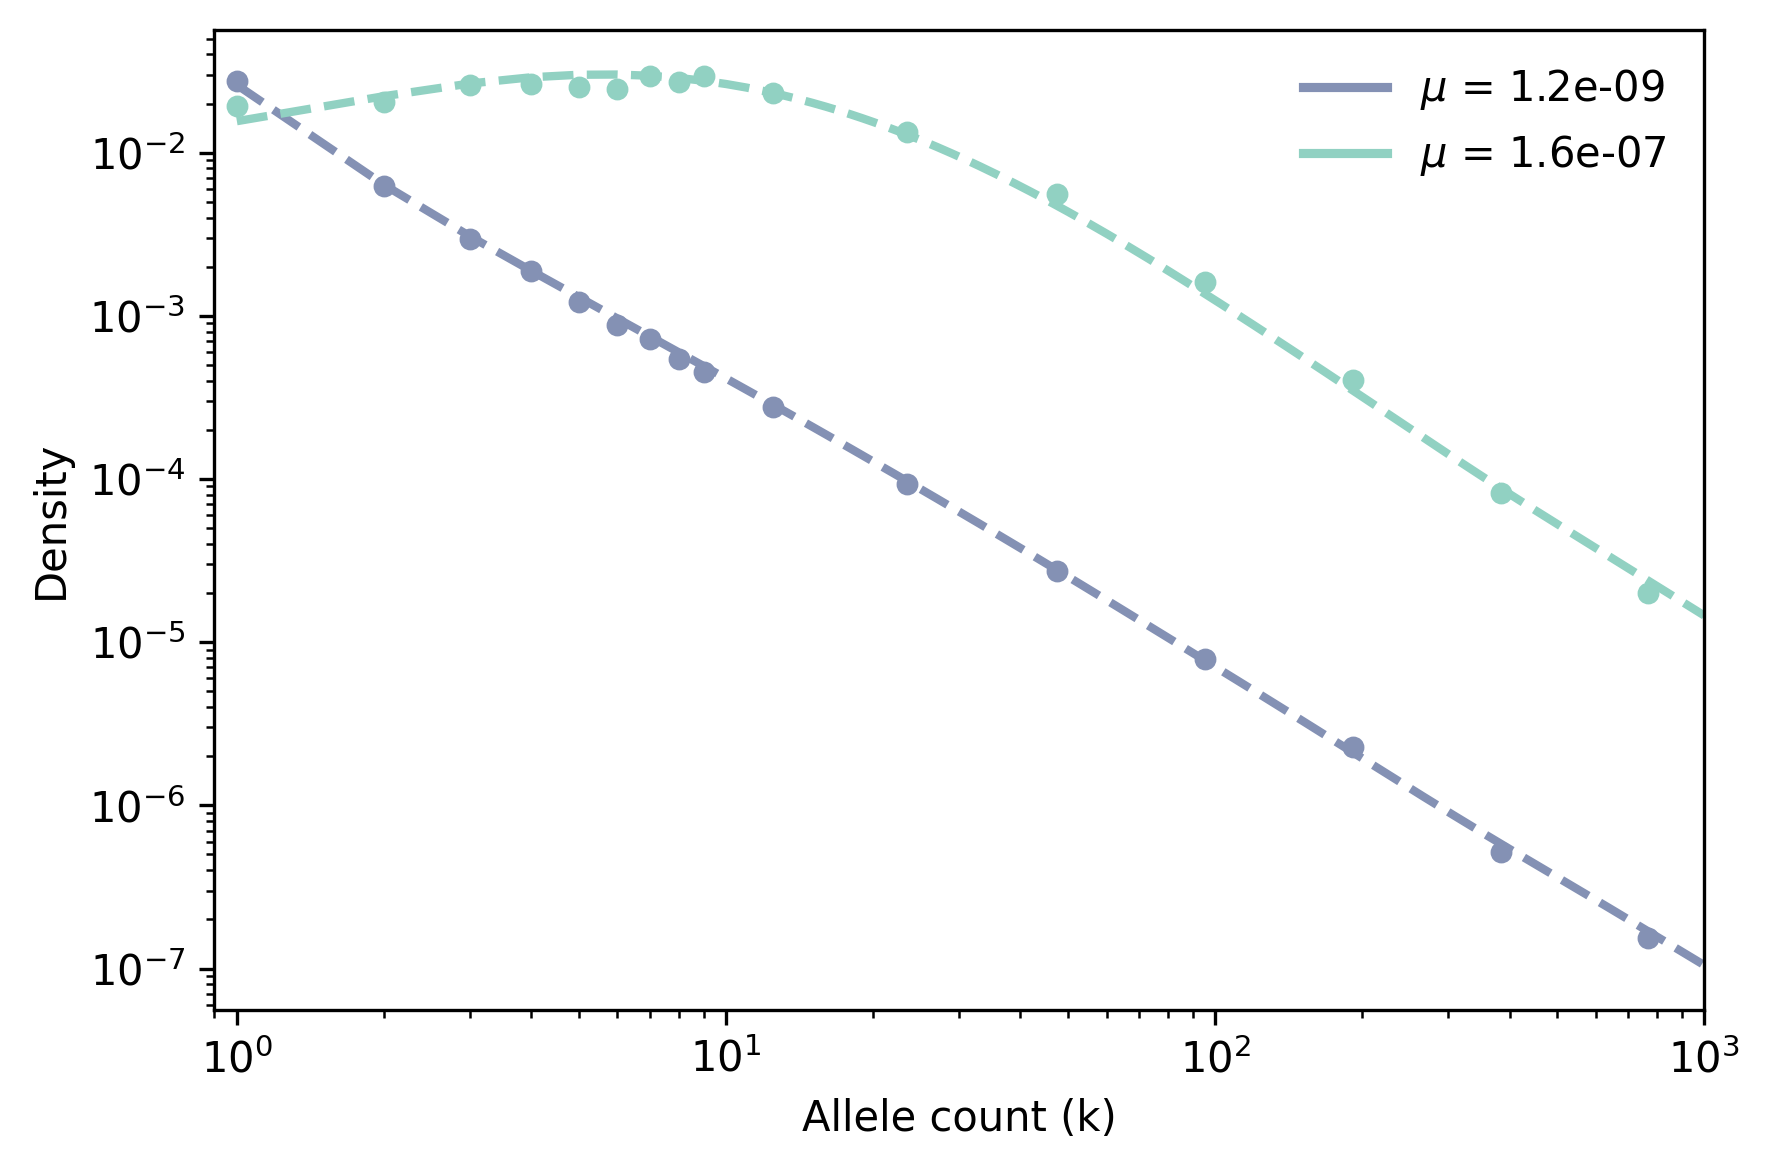

In [28]:
demography = "NFE"
run_SFS_validation(demography, epoch_no=3, MR_values= [0.020, 3.219], mu_low_mu = 2e-10, single_param = False, fig_save_file="../../../presentation_ASHG/figures/mut_rate_SFS.svg")